# Ejercicio Binning, imputacion, outliers, dummies etc
El siguiente Dataset contiene detalles de 1000 potenciales compradores de bicicletas, realizaremos un análisis exploratorio del mismo, imputando las variables que correspondan.

1. ¿Cuáles de las variables contienen valores nulos?
2. ¿Está Balanceada la variable target 'Purchased Bike'?
3. Imputar los valores nulos de Gender con el valor 'X'.
4. Imputar los valores nulos y outliers de Age con la media.
5. Eliminar los registros con valor nulo en Cars.
6. Generar columnas dummy para las variables Education y Occupation.
7. Definir una estrategia de imputación para las otras variables que corresponda.
8. Finalizar el análisis exploratorio con gráficos del dataset.

In [2]:
import pandas as pd
bike_buyers = pd.read_csv('https://raw.githubusercontent.com/pokengineer/DataScience/main/datasets/bike_buyers.csv')

In [3]:
bike_buyers

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike
0,12496,Married,Female,40000.0,1.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,Europe,42.0,No
1,24107,Married,Male,30000.0,3.0,Partial College,Clerical,Yes,1.0,0-1 Miles,Europe,43.0,No
2,14177,Married,Male,80000.0,5.0,Partial College,Professional,No,2.0,2-5 Miles,Europe,60.0,No
3,24381,Single,NaN,70000.0,0.0,Bachelors,Professional,Yes,1.0,5-10 Miles,Pacific,41.0,Yes
4,25597,Single,Male,30000.0,0.0,Bachelors,Clerical,No,0.0,0-1 Miles,Europe,36.0,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,23731,Married,Male,60000.0,2.0,High School,Professional,Yes,2.0,2-5 Miles,North America,54.0,Yes
996,28672,Single,Male,70000.0,4.0,Graduate Degree,Professional,Yes,0.0,2-5 Miles,North America,35.0,Yes
997,11809,Married,NaN,60000.0,2.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,North America,38.0,Yes
998,19664,Single,Male,100000.0,3.0,Bachelors,Management,No,3.0,1-2 Miles,North America,38.0,No


In [4]:
#bike_buyers.describe(include='all')
bike_buyers.isnull().any()


ID                  False
Marital Status       True
Gender               True
Income               True
Children             True
Education           False
Occupation          False
Home Owner           True
Cars                 True
Commute Distance    False
Region              False
Age                  True
Purchased Bike      False
dtype: bool

In [5]:
bike_buyers["Purchased Bike"].value_counts()

Purchased Bike
No     519
Yes    481
Name: count, dtype: int64

In [6]:
# 3. Imputar los valores nulos de Gender con el valor 'X'.
work_df = bike_buyers.copy()
work_df["Gender"] = bike_buyers["Gender"].fillna('X')
work_df

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike
0,12496,Married,Female,40000.0,1.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,Europe,42.0,No
1,24107,Married,Male,30000.0,3.0,Partial College,Clerical,Yes,1.0,0-1 Miles,Europe,43.0,No
2,14177,Married,Male,80000.0,5.0,Partial College,Professional,No,2.0,2-5 Miles,Europe,60.0,No
3,24381,Single,X,70000.0,0.0,Bachelors,Professional,Yes,1.0,5-10 Miles,Pacific,41.0,Yes
4,25597,Single,Male,30000.0,0.0,Bachelors,Clerical,No,0.0,0-1 Miles,Europe,36.0,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,23731,Married,Male,60000.0,2.0,High School,Professional,Yes,2.0,2-5 Miles,North America,54.0,Yes
996,28672,Single,Male,70000.0,4.0,Graduate Degree,Professional,Yes,0.0,2-5 Miles,North America,35.0,Yes
997,11809,Married,X,60000.0,2.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,North America,38.0,Yes
998,19664,Single,Male,100000.0,3.0,Bachelors,Management,No,3.0,1-2 Miles,North America,38.0,No


In [ ]:
#4. Imputar los valores nulos y outliers de Age con la media.
mean = work_df["Age"].mean()
work_df["Age"] = work_df["Age"].fillna(mean)
work_df[work_df["Age"] == mean]



,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike
58,25502,Married,Female,40000.0,1.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,Europe,-8.0,Yes
121,15922,Married,Male,150000.0,2.0,High School,Professional,Yes,4.0,0-1 Miles,Europe,160.0,No
212,20946,Single,Female,30000.0,0.0,Partial College,Clerical,No,1.0,2-5 Miles,Europe,0.0,No
250,22931,Married,Male,100000.0,5.0,Graduate Degree,Management,No,1.0,1-2 Miles,Pacific,78.0,Yes
371,22918,Single,Male,80000.0,5.0,Graduate Degree,Management,Yes,3.0,0-1 Miles,Pacific,-28.0,No
375,15628,Married,Female,40000.0,1.0,Bachelors,Skilled Manual,Yes,1.0,0-1 Miles,Europe,89.0,No
401,11555,Married,Female,40000.0,1.0,Bachelors,Clerical,Yes,0.0,0-1 Miles,Europe,80.0,No
595,18058,Single,Female,20000.0,3.0,High School,Skilled Manual,Yes,2.0,2-5 Miles,North America,78.0,No


In [ ]:

Q1 = work_df["Age"].quantile(0.25)
Q3 = work_df["Age"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = work_df[(work_df["Age"] < lower_bound) | (work_df["Age"] > upper_bound)]
print(outliers["Age"])

work_df['Age'] = work_df['Age'].where((work_df['Age'] < lower_bound) | (work_df['Age'] > upper_bound), work_df['Age'].median())

outliers = work_df[(work_df["Age"] < lower_bound) | (work_df["Age"] > upper_bound)]

print("Data after Replacing Outliers:\n", outliers["Age"])


58      -8.0
121    160.0
212      0.0
250     78.0
371    -28.0
375     89.0
401     80.0
595     78.0
Name: Age, dtype: float64
Data after Replacing Outliers:
 58      -8.0
121    160.0
212      0.0
250     78.0
371    -28.0
375     89.0
401     80.0
595     78.0
Name: Age, dtype: float64


In [7]:
# 5. Eliminar los registros con valor nulo en Cars.
work_df = work_df.dropna(subset=["Cars"])
work_df[work_df["Cars"].isnull()]

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike


In [8]:
# 6. Generar columnas dummy para las variables Education y Occupation.
work_df = pd.get_dummies(work_df, columns=["Education", "Occupation"])
work_df


,ID,Marital Status,Gender,Income,Children,Home Owner,Cars,Commute Distance,Region,Age,...,Education_Bachelors,Education_Graduate Degree,Education_High School,Education_Partial College,Education_Partial High School,Occupation_Clerical,Occupation_Management,Occupation_Manual,Occupation_Professional,Occupation_Skilled Manual
0,12496,Married,Female,40000.0,1.0,Yes,0.0,0-1 Miles,Europe,42.0,...,True,False,False,False,False,False,False,False,False,True
1,24107,Married,Male,30000.0,3.0,Yes,1.0,0-1 Miles,Europe,43.0,...,False,False,False,True,False,True,False,False,False,False
2,14177,Married,Male,80000.0,5.0,No,2.0,2-5 Miles,Europe,60.0,...,False,False,False,True,False,False,False,False,True,False
3,24381,Single,X,70000.0,0.0,Yes,1.0,5-10 Miles,Pacific,41.0,...,True,False,False,False,False,False,False,False,True,False
4,25597,Single,Male,30000.0,0.0,No,0.0,0-1 Miles,Europe,36.0,...,True,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,23731,Married,Male,60000.0,2.0,Yes,2.0,2-5 Miles,North America,54.0,...,False,False,True,False,False,False,False,False,True,False
996,28672,Single,Male,70000.0,4.0,Yes,0.0,2-5 Miles,North America,35.0,...,False,True,False,False,False,False,False,False,True,False
997,11809,Married,X,60000.0,2.0,Yes,0.0,0-1 Miles,North America,38.0,...,True,False,False,False,False,False,False,False,False,True
998,19664,Single,Male,100000.0,3.0,No,3.0,1-2 Miles,North America,38.0,...,True,False,False,False,False,False,True,False,False,False


In [9]:
#7. Definir una estrategia de imputación para las otras variables que corresponda.
work_df.isnull().any()
# Importar datos para Income o Children se podria usar la media, pero que ponemos Marital Status y Home Owner?

ID                               False
Marital Status                    True
Gender                           False
Income                            True
Children                          True
Home Owner                        True
Cars                             False
Commute Distance                 False
Region                           False
Age                              False
Purchased Bike                   False
Education_Bachelors              False
Education_Graduate Degree        False
Education_High School            False
Education_Partial College        False
Education_Partial High School    False
Occupation_Clerical              False
Occupation_Management            False
Occupation_Manual                False
Occupation_Professional          False
Occupation_Skilled Manual        False
dtype: bool

<Axes: >

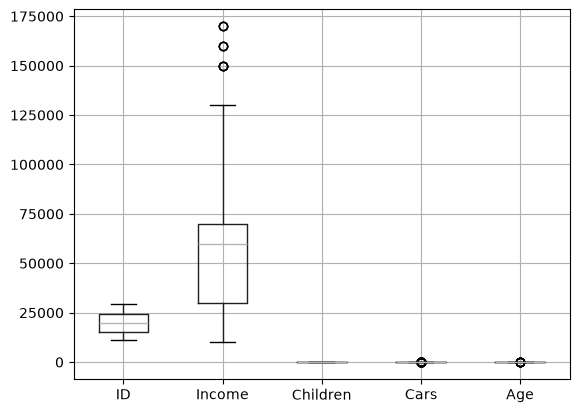

In [ ]:
bike_buyers.boxplot() # Interesantes outliers en Income, ademas de valores muy elevados. Se podria estandarizar??